# HWO DISRA Science Notebook Guide

This notebook is a guide for creating science notebooks using the DISRA (Dynamic Integrated Science Return Analysis) API
for the Habitable Worlds Observatory (HWO) project.

The goal of the API is to provide tools for generating notebooks which describe science cases
in a way that provides access to analysis products for the Science Tracability Matrix (STM).

## Quick Start

There are broadly three steps to analyzing a science case:

1. Identify the **science parameters** which the analysis will range over. For example, a range of fluxes or square degrees of sky coverage.
2. Model these parameters to determine what the **science yield** is across the parameter space and which parts of the space can satisfy the science requirements.
3. Model the exposure time necessary to complete the needed observations across the parameter space.
4. Select a **single point** in the parameter space as the chosen answer to the analysis. (This may change from spacecraft to spacecraft).

The DISRA notebook API is designed to support four functions within a science case analysis notebook.

1. Define science yield functions for modeling the **science parameter** space (yieldinators)
2. Calculate observation times over the parameter space (timeinators)
3. Visualize science yield and time results across different EAC (Engineering Analysis Case) telescope configurations
4. Collection of explanatory text for use in the observatory Science Traceability Matrix (STM)

The Yieldinator type is designed to support 'Panel 1' analysis that is independent of any
specific observatory. There are four defined analysis science value thresholds which can be
specified within a Yieldinator definition based on how substantially passing a given threshold
would improve current scientific understanding of a phenomenon.


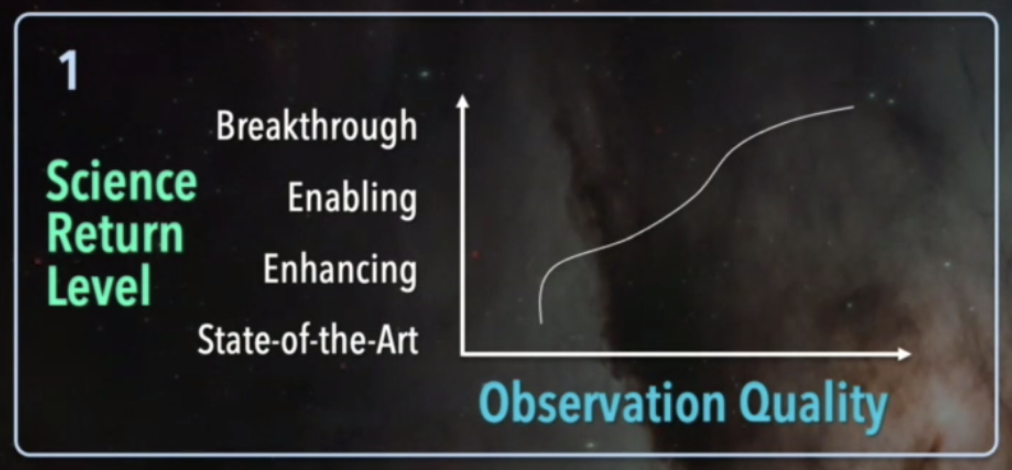

The Timeinator type is designed to support 'Panel 2' analysis, answering the question "what is possible with a given observatory and how much time does it take?"

This extends the Yieldinator analysis to a specific EAC observatory model for exposure time calculation of desired observations.

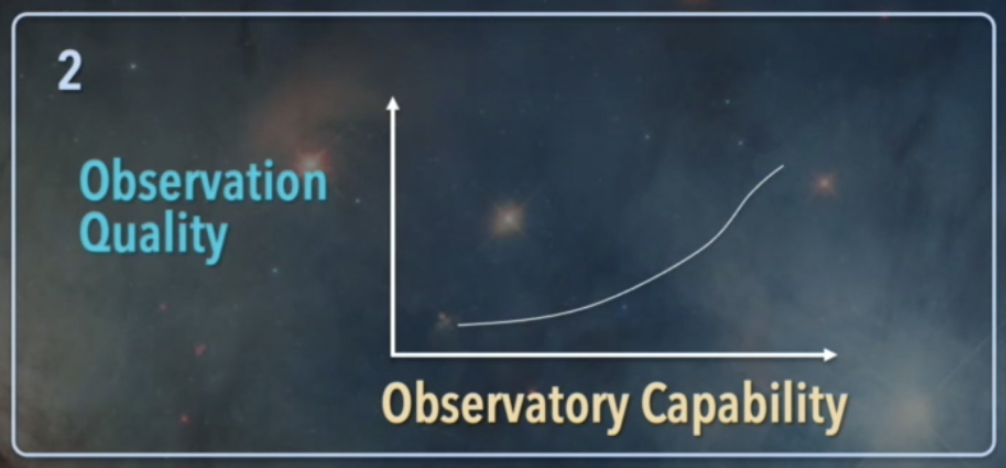


The Science Traceability Matrix requires these text fields

**GOAL:** \
**OBJECTIVE:** \
**PHYSICAL_PARAMETERS:** \
**OBSERVATIONS:** \
**INSTRUMENT_REQUIREMENTS:** \
**MISSION_REQUIREMENTS:**

And these are optional:

**CODE PURPOSE:** \
**EXPECTED_PERFORMANCE:**

When processing the notebook the DISRA framework will capture all text between the keyword **and the next keyword or empty line** and associate it with the keyword starting the line.

## 1. Basic Setup

The DISRA API is accessed through the `DisraNBApi.get_instance()` method, which returns the DISRA object.

In [10]:
!pip install hwo_disra


[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [11]:

from hwo_disra.api.notebook_api import DisraNBApi
from hwo_disra.Types import ScienceValue, Range, Time

# Get the singleton API instance
api = DisraNBApi.get_instance()

## 2. Modeling science parameters

Science parameter modeling for 'panel 1' is supported through the Yieldinator class.
This class enables the specification of a **name** for a given calculation,
the **thresholds** that characterize the science value of the science yield outputs,
the **independent variables** that define the parameter space we are modeling,
and the **yield_function** which computes the **science yield** at a point in the parameter space defined by the variables.

A yieldinator has these inputs:
- **name**: Identifier for this yield computation.
- **thresholds**: Science value thresholds (e.g., STATE_OF_THE_ART, EHANCING, ENABLING, BREAKTHROUGH)
- **variables**: Independent variables that define the parameter space to explore for analysis.
- **yield_function**: A function that computes the **science yield** at a point in the parameter space.
- **yield_units**: An astropy.units Unit or a string describing the units the function returns. Used for display.

In [12]:
import numpy as np
import astropy.units as u


# Example: Sky Survey with Field of View Trade
# This demonstrates a hypothetical observatory design trade study where we explore
# how survey depth and sky coverage affect the number of detected sources.

def calculate_survey_yield(survey_depth_mag, survey_area_deg2):
    """Calculate number of detected sources in an imaging survey.
    
    This uses a simple model where:
    - Deeper surveys (fainter limiting magnitude) detect more sources per unit area
    - Source counts follow a power law: N(<m) ∝ 10^(0.6*m)
    - Total detections = source density × survey area
    """
    # Source density increases exponentially with depth (Euclidean slope ~0.6)
    # Normalized so that mag=25 gives ~100 sources/deg²
    sources_per_deg2 = 100 * 10**(0.6 * (survey_depth_mag - 25))
    
    # Total detections = density × area
    total_detections = sources_per_deg2 * survey_area_deg2
    
    return total_detections

# Create the yieldinator for the survey
yielder = api.yieldinator(
    name='ImagingSurvey',
    # Thresholds: need 500 detections to be enhancing, 2000 to be enabling
    thresholds={ScienceValue.ENHANCING: 200, ScienceValue.ENABLING: 400},
    variables={
        'survey_depth_mag': Range(24, 28, u.mag),      # Survey limiting magnitude
        'survey_area_deg2': Range(0.001, 0.1, u.deg**2)  # Sky coverage in sq degrees
    },
    yield_units='number of sources detected',
    yield_function=calculate_survey_yield
)

# Evaluate the yieldinator
yield_results = api.evaluate(yielder, register=True)
example_point = yield_results[0].sample_points[5]
# The keys in the points returned are the names of the independent variables plus 'yield' and 'time'
# 'time' = None for yieldinators
print(list(example_point.keys()))
print(f"Example: mag={example_point['survey_depth_mag']:.1f}, area={example_point['survey_area_deg2']:.4f} deg² → {example_point['yield']:.0f} detections")


['yield', 'time', 'survey_depth_mag', 'survey_area_deg2']
Example: mag=24.0, area=0.0111 deg² → 0 detections


### Results Structure

When you call `api.evaluate()`, it returns a list of `YieldEvaluation` objects containing:
- `sample_points`: Dictionary with parameter values and calculated results.
- `units`: A dictionary of units based on the inputs to the Yieldinator or Timeinator.
- `eac`: The EAC configuration used (only populated for Timeinator).

A list of `YieldEvaluation` objects can be plotted in standard forms by the DISRA API object. TBD what set will be supported.

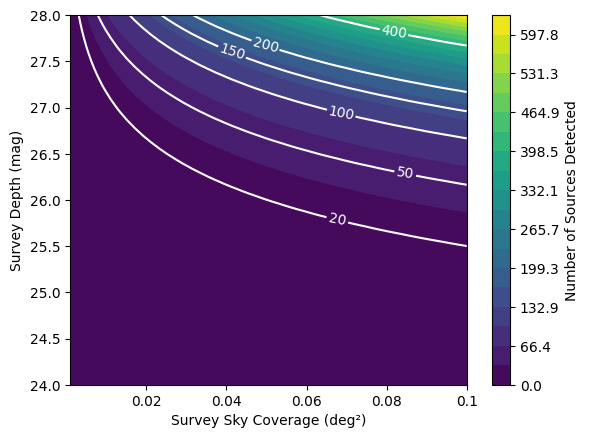

In [13]:
api.contour_plot_yield(yield_results,
                       # The keys from the points in YieldEvaluation.sample_points field.
                       x_key='survey_area_deg2', 
                       y_key='survey_depth_mag', 
                       z_key='yield',
                       contour_levels=[20, 50, 100, 150] + yielder.levels(),
                       axis_labels={
                           'survey_area_deg2': 'Survey Sky Coverage (deg²)',
                           'survey_depth_mag': 'Survey Depth (mag)',
                           'yield': 'Number of Sources Detected'
                       })


## 3. Creating a Timeinator

A timeinator calculates observation time required to achieve the science yield.
It takes the yieldinator and adds time calculations based on EAC configurations.

In [14]:
import warnings

# Timeinator: Calculate total survey time including field-of-view effects
# This demonstrates realistic observatory constraints where the number of pointings
# and overheads significantly affect the total survey time.

def calculate_survey_time(eac, yield_value, survey_depth_mag, survey_area_deg2) -> Time:
    """Calculate total observation time for an imaging survey.
    
    Key factors:
    - Exposure time per pointing depends on limiting magnitude and telescope aperture
    - Number of pointings = survey_area / camera_FOV (rounded up)
    - Each pointing includes observing overhead
    """
    # Camera field of view (assumed ~0.00167 deg² = 2'×3' like HRI)
    camera_fov_deg2 = 0.00167
    
    # Number of pointings needed to cover the survey area
    n_pointings = np.ceil(survey_area_deg2 / camera_fov_deg2)
    
    # Exposure time per pointing to reach the survey depth (in seconds)
    # Using SNR=5 as a typical detection threshold
    single_exposure_sec = api.exptime_from_magnitude_fun(snr_goal=5, rband_index=5)(eac, survey_depth_mag)
    
    # Overhead per pointing (readout, slew, settle) in seconds
    overhead_per_pointing_sec = 120
    
    # Total time = (exposure + overhead) × number of pointings
    total_time_sec = (single_exposure_sec + overhead_per_pointing_sec) * n_pointings
    
    # Convert to days
    total_time_days = total_time_sec / (24 * 3600)
    
    return Time(total_time_days)

timer = api.timeinator(yielder, timeinate=calculate_survey_time, units=u.day)

warnings.filterwarnings("ignore", message="divide by zero encountered in log")
# Evaluate with steps=5 for reasonable resolution
time_results = api.evaluate(timer, steps=5, register=True)

# Print an example
example_eval = time_results[0]
example_pt = example_eval.sample_points[10]
print(f"Example for {example_eval.eac}:")
print(f"  mag={example_pt['survey_depth_mag']:.1f}, area={example_pt['survey_area_deg2']:.4f} deg²")
print(f"  → {example_pt['yield']:.0f} detections in {example_pt['time']:.2f} days")


Example for EAC1:
  mag=26.0, area=0.0010 deg²
  → 0 detections in 0.00 days


Like the yieldinator, the evaluate method returns a list of `YieldEvaluation` objects. This list can be plotted with supporting api methods.

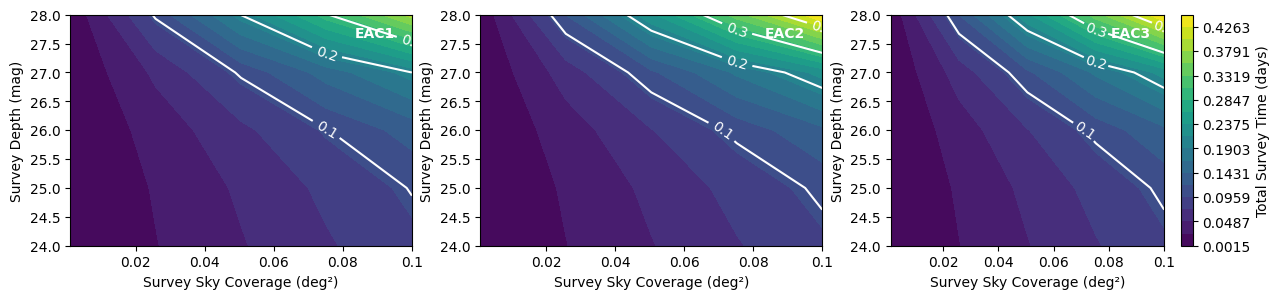

In [15]:
api.contour_plot_yield(time_results, 
                       x_key='survey_area_deg2', 
                       y_key='survey_depth_mag', 
                       z_key='time',
                       contour_levels=[0.1, 0.2, 0.3, 0.4],
                       figsize=(15, 3),
                       axis_labels={
                           'survey_area_deg2': 'Survey Sky Coverage (deg²)',
                           'survey_depth_mag': 'Survey Depth (mag)',
                           'time': 'Total Survey Time (days)'
                       })


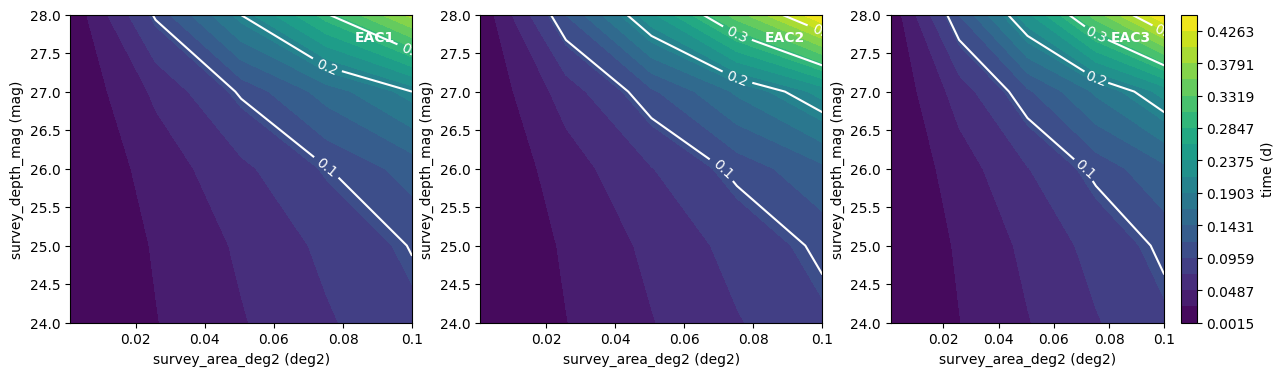

In [16]:
# Create contour plots showing time vs parameters for each EAC
# This shows how survey time scales differently across telescope configurations
api.plotinator().contour_plot(
    [e.sample_points for e in time_results],
    'survey_area_deg2', 'survey_depth_mag', 'time',
    titles=[e.eac for e in time_results],
    units = timer.units(),
    contour_levels=[0.1, 0.2, 0.3, 0.4],  # days
    figsize=(15, 4)
)


## 5. STM Data Registration

For Science Traceability Matrix integration, register key science parameters and results.

In [17]:
# Register chosen parameters for this science case
# These represent the final selected survey parameters
api.register_chosen_parameters({
    'survey_depth': 26.5,     # mag
    'survey_area': 0.02,      # deg²
    'min_detections': 500,    # sources
    'survey_time_days': 1.5   # days (for EAC2)
})


u
**SCIENCE_GOAL:** Characterize terrestrial exoplanets within $target\_distance$ pc

**OBJECTIVE:** Detect and measure atmospheric composition of $required\_targets$ planets

**REQUIREMENT:** Achieve limiting magnitude of $limiting\_magnitude$ with S/N > 10


### Matrix Lookup Yieldinator

In some cases it will be useful to generate a precomputed matrix and sample this for yield calculations.
To support this case we have a specific API for creating a yieldinator from a matrix.

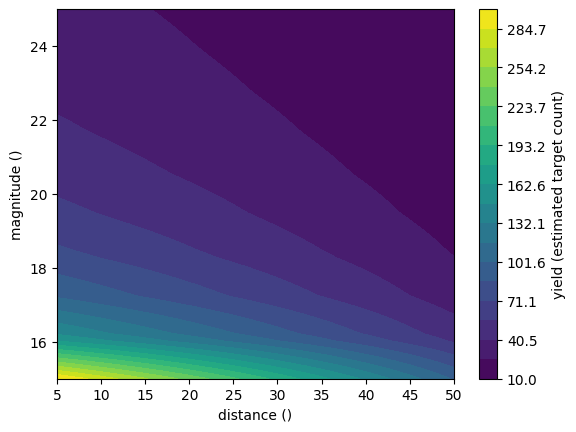

In [18]:
# Example: Using pre-computed yield matrices

# Create sample yield matrix
distances = np.linspace(5, 50, 10)
magnitudes = np.linspace(15, 25, 10)
yield_matrix = np.outer(100/distances, 30-magnitudes)

matrix_yielder = api.matrix_lookup_yieldinator(magnitudes, distances, yield_matrix,
    variable_x = 'magnitude',
    variable_y = 'distance',
    yield_units = 'estimated target count',
    thresholds={ScienceValue.ENABLING: 50},
)

api.contour_plot_yield(api.evaluate(matrix_yielder), x_key='distance', y_key='magnitude', z_key='yield')

## Best Practices

1. **Always use API**: Call `DisraNBApi.get_instance()` to access the API object.
2. **Register timeinators and yieldinators**: Use `register=True` when the results of an evaluation should be exported for DISRA STM analysis
3. **Document thresholds**: Clearly define science value thresholds
4. **Use meaningful names**: Give descriptive names to yieldinators
5. **Include units**: Units are descriptive in the yieldinator and timeinator. They are not currently used in calculations due to performance issues with Quantity objects.

## API Quick Reference

| Method | Purpose | Key Parameters |
|--------|---------|---------------|
| `api.yieldinator()` | Create yield calculator | `name`, `thresholds`, `variables`, `yield_function` |
| `api.timeinator()` | Create time calculator | `yieldinator`, `time_function` |
| `api.evaluate()` | Run calculations | `evaluator`, `register=True/False` |
| `api.plotinator()` | Access plotting tools | Returns plotinator instance |
| `api.register_chosen_parameters()` | Save final parameters | `dict` of parameter values |
| `api.register_stm_variable()` | Register STM variables | `key`, `value` for templates |